In [1]:
import sys
print(sys.executable)

c:\Users\Alvin\anaconda3\python.exe


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.20.0
Num GPUs Available: 0


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# -------------------------------
# CONFIGURATION
# -------------------------------
seed = 0
np.random.seed(seed)

# Load data
X_train = pd.read_csv("../../Datasets/X_train_purified.csv")
X_test = pd.read_csv("../../Datasets/X_test_purified.csv")
y_train = pd.read_csv("../../Datasets/Y_train_purified.csv").values.ravel()
y_test = pd.read_csv("../../Datasets/Y_test_purified.csv").values.ravel()

# Label encode
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
n_classes = len(le.classes_)

# SMOTE
sm = SMOTE(random_state=seed)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train_enc)

# One-hot encode labels
y_train_oh = to_categorical(y_train_sm, num_classes=n_classes)
y_test_oh = to_categorical(y_test_enc, num_classes=n_classes)

input_dim = X_train_sm.shape[1]

# -------------------------------
# AUTOENCODER (fixed)
# -------------------------------
def build_autoencoder(input_dim, encoding_dim=500, hidden_dim1=5000, hidden_dim2=2000, 
                      l2_reg=1e-14, learning_rate=3e-5):
    """Build encoder + autoencoder"""
    inp = Input(shape=(input_dim,))
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = ReLU()(x)
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    encoded = Dense(encoding_dim, kernel_regularizer=regularizers.l2(l2_reg))(x)
    encoded = ReLU()(encoded)
    
    # Decoder
    x = Dense(hidden_dim2, kernel_regularizer=regularizers.l2(l2_reg))(encoded)
    x = ReLU()(x)
    x = Dense(hidden_dim1, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = ReLU()(x)
    decoded = Dense(input_dim, activation='linear')(x)
    
    autoencoder = Model(inputs=inp, outputs=decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['accuracy'])
    
    encoder = Model(inputs=inp, outputs=encoded)
    return autoencoder, encoder

# Apply AE before the main pipeline (standard practice if AE is not being tuned)
autoencoder, encoder = build_autoencoder(X_train.shape[1])
autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, verbose=1, shuffle=True) 

X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.0020 - loss: 0.1335
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.0020 - loss: 0.0176   
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.0668 - loss: 0.0087
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.2105 - loss: 0.0076
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3198 - loss: 0.0074
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0648 - loss: 0.0073
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1012 - loss: 0.0073
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0648 - loss: 0.0073
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0547 - loss: 0.0073
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0587 - loss: 0.0072
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.0445 - loss: 0.0071
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accura

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[CV 1/5] END nn__batch_size=16, nn__model__activation=relu, nn__model__dropout_rate1=0.2, nn__model__dropout_rate2=0.2, nn__model__hidden_dim=200, nn__model__learning_rate=0.002, smote__k_neighbors=5;, score=(train=0.955, test=0.769) total time=  36.7s
[CV 2/5] END nn__batch_size=16, nn__model__activation=relu, nn__model__dropout_rate1=0.2, nn__model__dropout_rate2=0.2, nn__model__hidden_dim=200, nn__model__learning_rate=0.002, smote__k_neighbors=5;, score=(train=0.940, test=0.831) total time=  11.3s
[CV 3/5] END nn__batch_size=16, nn__model__activation=relu, nn__model__dropout_rate1=0.2, nn__model__dropout_rate2=0.2, nn__model__hidden_dim=200, nn__model__learning_rate=0.002, smote__k_neighbors=5;, score=(train=0.952, test=0.772) total time=  56.5s
[CV 4/5] END nn__batch_size=16, nn__model__activation=relu, nn__model__dropout_rate1=0.2, nn__model__dropout_rate2=0.2, nn__model__hidden_dim=200, nn__model__learning_rate=0.002, smote__k_neighbors=5;, score=(train=0.922, test=0.753) total t

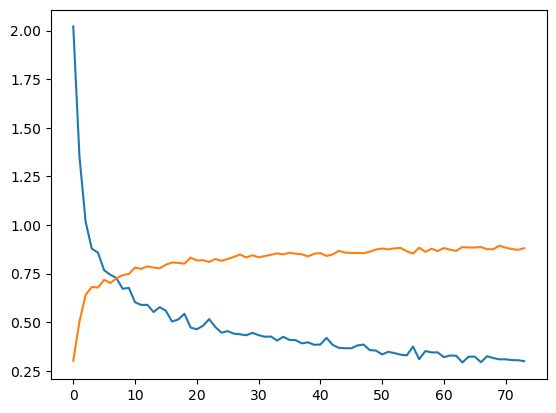


Classification Report:
              precision    recall  f1-score   support

       Basal       0.89      0.94      0.91        17
        Her2       0.50      0.67      0.57         6
        LumA       0.84      0.67      0.75        57
        LumB       0.52      0.65      0.58        26
      Normal       0.84      0.94      0.89        17

    accuracy                           0.74       123
   macro avg       0.72      0.77      0.74       123
weighted avg       0.76      0.74      0.74       123



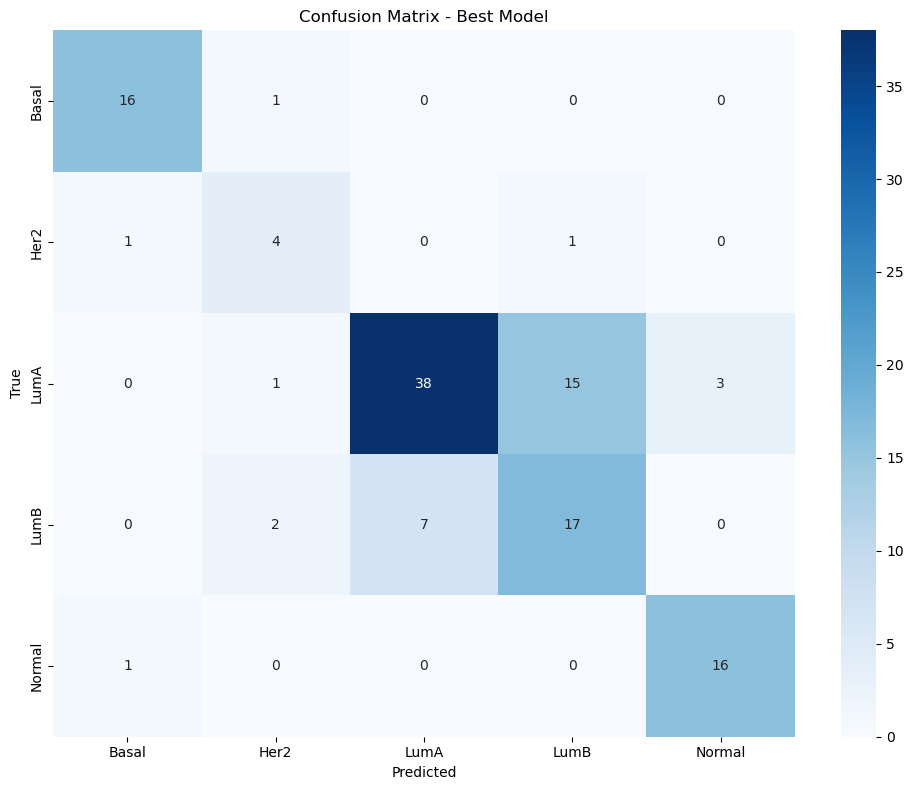


TOP 10 CONFIGURATIONS:

Rank 1:
  Score: 0.7805 (+/- 0.0332)
  Parameters: {'smote__k_neighbors': 5, 'nn__model__learning_rate': 0.0001, 'nn__model__hidden_dim': 200, 'nn__model__dropout_rate2': 0.4, 'nn__model__dropout_rate1': 0.2, 'nn__model__activation': 'leakyrelu', 'nn__batch_size': 64}

Rank 2:
  Score: 0.7750 (+/- 0.0112)
  Parameters: {'smote__k_neighbors': 3, 'nn__model__learning_rate': 0.002, 'nn__model__hidden_dim': 200, 'nn__model__dropout_rate2': 0.4, 'nn__model__dropout_rate1': 0.1, 'nn__model__activation': 'tanh', 'nn__batch_size': 64}

Rank 3:
  Score: 0.7737 (+/- 0.0374)
  Parameters: {'smote__k_neighbors': 7, 'nn__model__learning_rate': 0.002, 'nn__model__hidden_dim': 200, 'nn__model__dropout_rate2': 0.4, 'nn__model__dropout_rate1': 0.1, 'nn__model__activation': 'relu', 'nn__batch_size': 32}

Rank 4:
  Score: 0.7730 (+/- 0.0271)
  Parameters: {'smote__k_neighbors': 5, 'nn__model__learning_rate': 0.0001, 'nn__model__hidden_dim': 200, 'nn__model__dropout_rate2': 0.3, '

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
import joblib
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline


class HistoryLogger(tf.keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        # This will stay attached to the model after RandomizedSearchCV finishes
        self.model.final_history = self.model.history.history

def create_classifier(hidden_dim=200, dropout_rate1=0.2, dropout_rate2=0.3, 
                      learning_rate=2e-5, activation='relu'):
    inp = Input(shape=(X_train_encoded.shape[1],))
    x = BatchNormalization()(inp)
    x = Dropout(dropout_rate1, seed=seed)(x)

    # Activation
    if activation == 'leakyrelu':
        x = Dense(hidden_dim)(x)
        x = LeakyReLU(negative_slope=0.01)(x)
    elif activation == 'relu':
        x = Dense(hidden_dim)(x)
        x = ReLU()(x)
    else:
        x = Dense(hidden_dim, activation='tanh')(x)

    x = BatchNormalization()(x)
    x = Dropout(dropout_rate2, seed=seed)(x)
    out = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


# Wrap with KerasClassifier
clf = KerasClassifier(
    model=create_classifier,
    epochs=100, 
    verbose=0,
    loss='sparse_categorical_crossentropy',
    random_state=seed,
    callbacks=[EarlyStopping(monitor='loss', patience=10, restore_best_weights=True), HistoryLogger()]

)


pipeline = Pipeline([
    ('smote', SMOTE(random_state=seed)),
    ('nn', clf) # Your KerasClassifier
])

# -------------------------------
# RANDOMIZED SEARCH
# -------------------------------
param_dist = {
    'smote__k_neighbors': [3, 5, 7],
    'nn__model__hidden_dim': [200],
    'nn__model__dropout_rate1': [0.1, 0.2, 0.3],
    'nn__model__dropout_rate2': [0.1, 0.2, 0.3, 0.4, 0.5],
    'nn__model__learning_rate': [0.01, 0.002, 0.001, 0.0001],
    'nn__model__activation': ['relu', 'tanh', 'leakyrelu'],
    'nn__batch_size': [16, 32, 64],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=cv_strat,
    n_jobs=1,  
    random_state=seed,
    return_train_score=True,
    verbose=3
)
start = time.time()
random_search.fit(X_train_encoded, y_train_enc)
end = time.time()
print(f"RandomizedSearchCV completed in {(end-start)/60:.2f} minutes")

# -------------------------------
# EVALUATION
# -------------------------------
# Test on held-out test set
test_acc = random_search.score(X_test_encoded, y_test_enc)
print(f"Test set Score: {test_acc:.4f}")

best_model = random_search.best_estimator_
final_history = best_model.named_steps['nn'].model_.final_history


joblib.dump(best_model, "NN_SMOTE_RS_AE_Purified_bestmodel.pkl")
print("Best estimator saved to 'NN_SMOTE_RS_AE_Purified_bestmodel.pkl'")


plt.plot(final_history['loss'], label='Loss')
plt.plot(final_history['accuracy'], label='Accuracy')
plt.show()


y_pred_classes = best_model.predict(X_test_encoded)
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.show()


# Create results dataframe
results_df = pd.DataFrame(random_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

# Show top 10 configurations
print("\n" + "="*80)
print("TOP 10 CONFIGURATIONS:")
print("="*80)
top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
for idx, row in top_10.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Parameters: {row['params']}")

In [5]:
#YOU CAN DELETE THIS I FIXED IT ABOVE JUST RAN AGAIN BECAUSE OF PREVIOUS ERROR 

# -------------------------------
# EVALUATION
# -------------------------------
# Test on held-out test set
# test_acc = random_search.score(X_test_encoded, y_test_enc)
# print(f"Test set Score: {test_acc:.4f}")

# best_model = random_search.best_estimator_
# final_history = best_model.named_steps['nn'].model_.final_history


# joblib.dump(best_model, "NN_SMOTE_RS_AE_bestmodel.pkl")
# print("Best estimator saved to 'NN_SMOTE_RS_AE_bestmodel.pkl'")


# plt.plot(final_history['loss'], label='Loss')
# plt.plot(final_history['accuracy'], label='Accuracy')
# plt.show()


# y_pred_classes = best_model.predict(X_test_encoded)
# print("\nClassification Report:")
# print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# cm = confusion_matrix(y_test_enc, y_pred_classes)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=le.classes_, yticklabels=le.classes_)
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix - Best Model')
# plt.tight_layout()
# plt.show()


# Create results dataframe
# results_df = pd.DataFrame(random_search.cv_results_)
# results_df = results_df.sort_values('rank_test_score')

# # Show top 10 configurations
# print("\n" + "="*80)
# print("TOP 10 CONFIGURATIONS:")
# print("="*80)
# top_10 = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
# for idx, row in top_10.iterrows():
#     print(f"\nRank {int(row['rank_test_score'])}:")
#     print(f"  Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
#     print(f"  Parameters: {row['params']}")


Classification Report (Classifier):
              precision    recall  f1-score   support

       Basal       0.89      0.94      0.91        17
        Her2       0.50      0.67      0.57         6
        LumA       0.84      0.67      0.75        57
        LumB       0.52      0.65      0.58        26
      Normal       0.84      0.94      0.89        17

    accuracy                           0.74       123
   macro avg       0.72      0.77      0.74       123
weighted avg       0.76      0.74      0.74       123



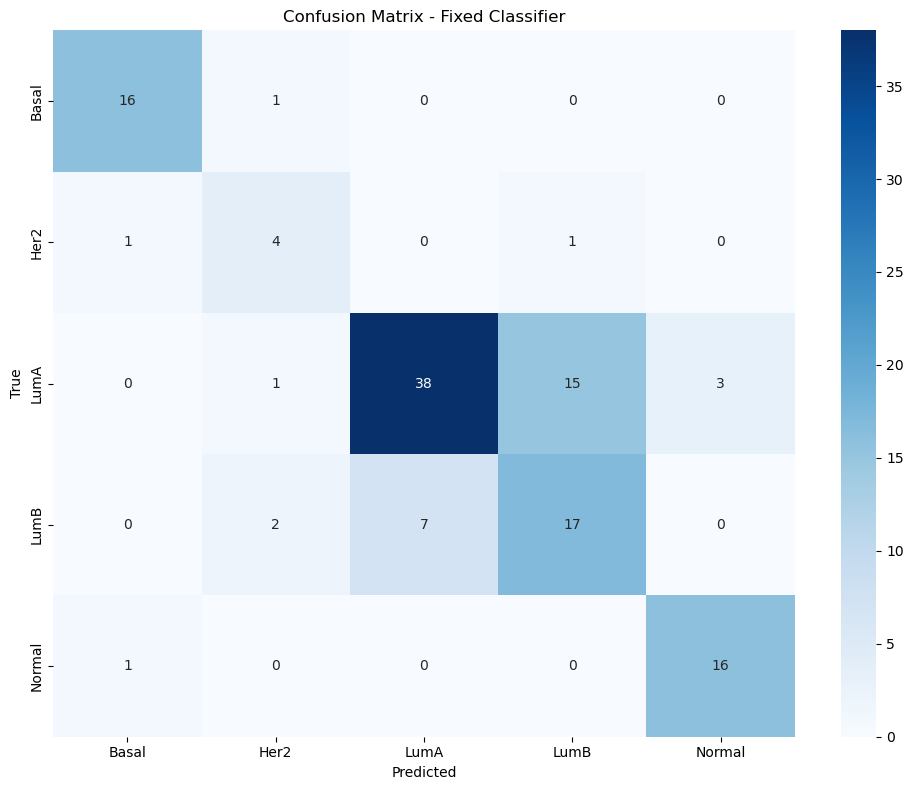

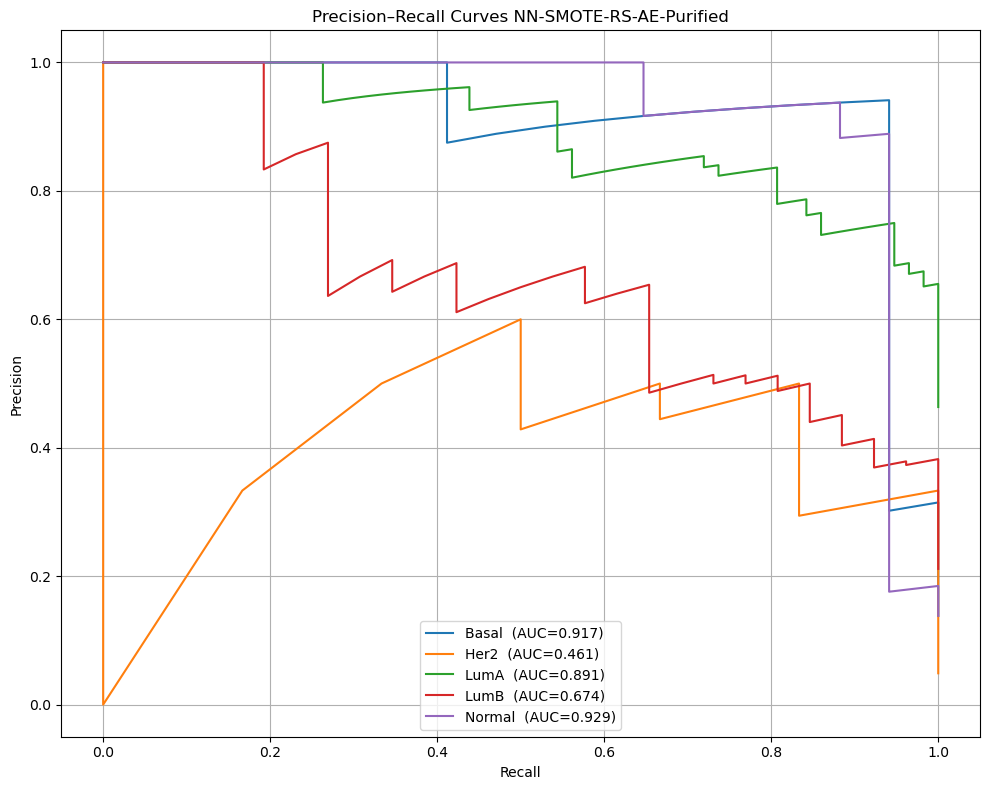

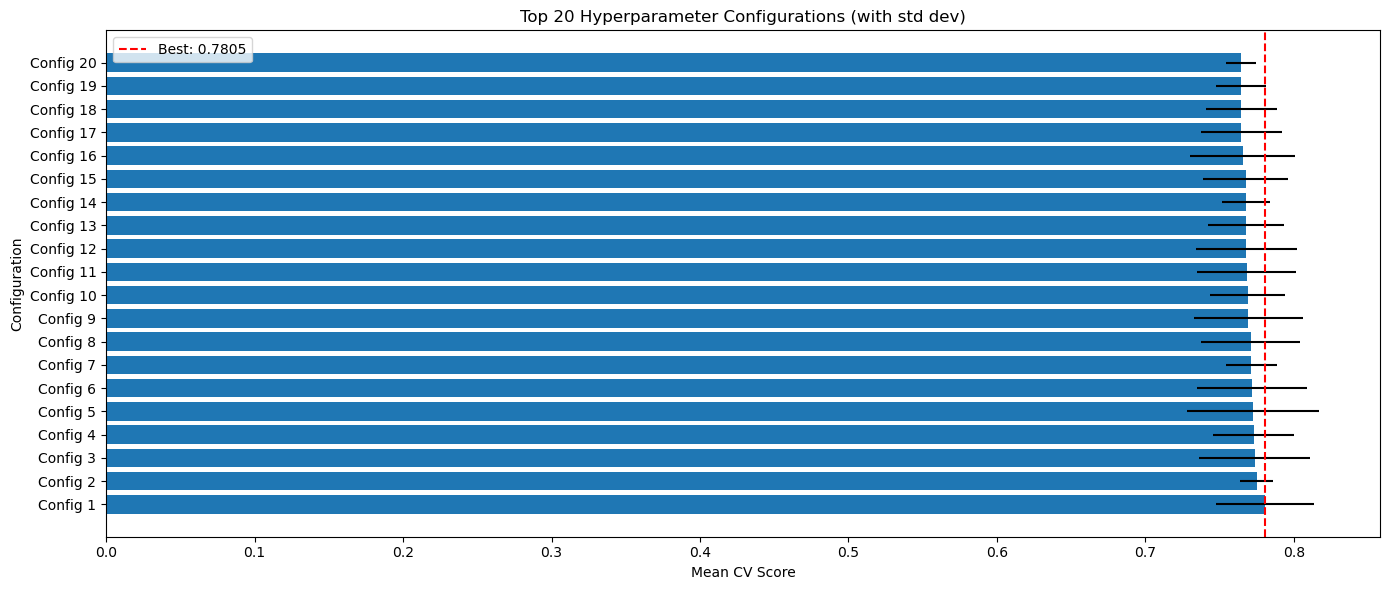


HYPERPARAMETER ANALYSIS:

smote__k_neighbors:
  3: appears 4/10 times in top 10
  5: appears 3/10 times in top 10
  7: appears 3/10 times in top 10

nn__model__activation:
  relu: appears 4/10 times in top 10
  leakyrelu: appears 3/10 times in top 10
  tanh: appears 3/10 times in top 10

nn__model__learning_rate:
  0.002: appears 4/10 times in top 10
  0.0001: appears 3/10 times in top 10
  0.001: appears 2/10 times in top 10
  0.01: appears 1/10 times in top 10

nn__batch_size:
  64: appears 7/10 times in top 10
  32: appears 2/10 times in top 10
  16: appears 1/10 times in top 10

nn__model__dropout_rate1:
  0.1: appears 5/10 times in top 10
  0.2: appears 4/10 times in top 10
  0.3: appears 1/10 times in top 10

nn__model__dropout_rate2:
  0.4: appears 4/10 times in top 10
  0.3: appears 2/10 times in top 10
  0.2: appears 2/10 times in top 10
  0.5: appears 2/10 times in top 10


C:\Users\Alvin\AppData\Local\Temp\ipykernel_29096\524196744.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])


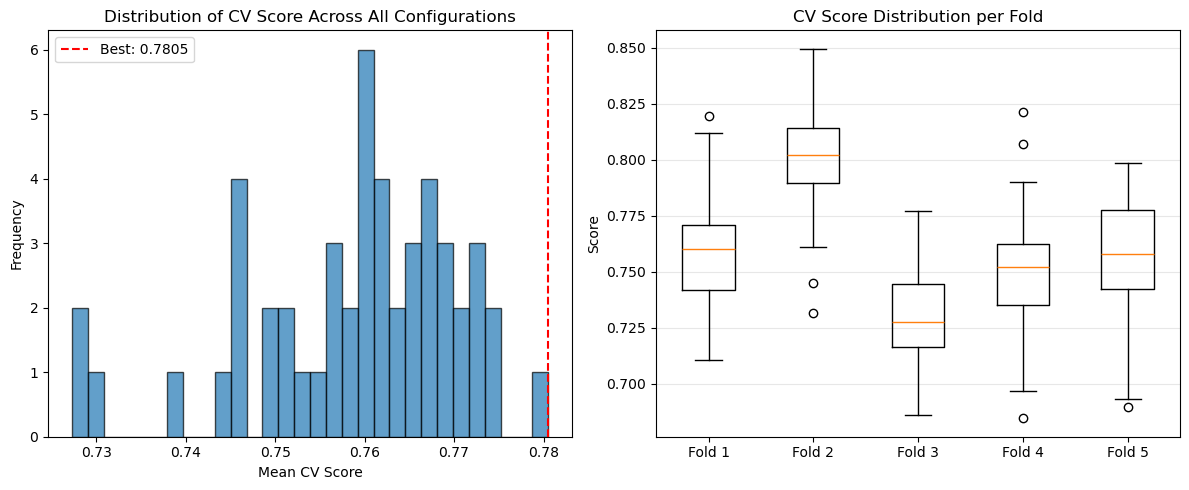


SUMMARY STATISTICS:
Best CV Score: 0.7805
Test Score: 0.7442
Mean CV Score (all configs): 0.7590
Std CV Score (all configs): 0.0119
Min CV Score: 0.7273
Max CV Score: 0.7805


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve,average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
from typing import Counter

# Predict probabilities and classes
y_pred_proba = best_model.predict_proba(X_test_encoded)
y_pred_classes = best_model.predict(X_test_encoded)

# -------------------------------
# CLASSIFICATION REPORT
# -------------------------------
print("\nClassification Report (Classifier):")
print(classification_report(y_test_enc, y_pred_classes, target_names=le.classes_))

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test_enc, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fixed Classifier')
plt.tight_layout()
plt.show()

# -------------------------------
# PRECISION–RECALL CURVE (MICRO-AVERAGE)
# -------------------------------
# Convert predictions into the max probability for each sample
y_score = np.max(y_pred_proba, axis=1)

# Convert true labels to 1 if correct, 0 otherwise
y_test_binarized = label_binarize(y_test_enc, classes=range(len(le.classes_)))

plt.figure(figsize=(10, 8))


for i, class_name in enumerate(le.classes_):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_score = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name}  (AUC={auc_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves NN-SMOTE-RS-AE-Purified")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
#  Results Visualization
# ------------------------------------------------------------------

results_df = pd.DataFrame(random_search.cv_results_)

# Plot top 20 configurations
plt.figure(figsize=(14, 6))
top_20 = results_df.nsmallest(20, 'rank_test_score')

plt.barh(range(len(top_20)), top_20['mean_test_score'], xerr=top_20['std_test_score'])
plt.yticks(range(len(top_20)), [f"Config {i+1}" for i in range(len(top_20))])
plt.xlabel('Mean CV Score')
plt.ylabel('Configuration')
plt.title('Top 20 Hyperparameter Configurations (with std dev)')
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', label=f'Best: {random_search.best_score_:.4f}')
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Hyperparameter importance analysis
# ------------------------------------------------------------------

print("\n" + "="*80)
print("HYPERPARAMETER ANALYSIS:")
print("="*80)

top_10_configs = results_df.nsmallest(10, 'rank_test_score')

for param in ['smote__k_neighbors', 'nn__model__activation', 
              'nn__model__learning_rate', 'nn__batch_size', 'nn__model__dropout_rate1', 'nn__model__dropout_rate2']:
    print(f"\n{param}:")
    param_values = [config[param] for config in top_10_configs['params']]
    counts = Counter(param_values)
    for value, count in counts.most_common():
        print(f"  {value}: appears {count}/10 times in top 10")

# ------------------------------------------------------------------
# CV Accuracy Distribution
# ------------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Histogram of all CV Score
plt.subplot(1, 2, 1)
plt.hist(results_df['mean_test_score'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=random_search.best_score_, color='r', linestyle='--', 
            label=f'Best: {random_search.best_score_:.4f}')
plt.xlabel('Mean CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Score Across All Configurations')
plt.legend()

# Box plot (adjust to number of folds)
plt.subplot(1, 2, 2)
n_folds = random_search.cv.n_splits  # dynamically use actual folds
cv_scores = [results_df[f'split{i}_test_score'] for i in range(n_folds)]
plt.boxplot(cv_scores, labels=[f'Fold {i+1}' for i in range(n_folds)])
plt.ylabel('Score')
plt.title('CV Score Distribution per Fold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS:")
print("="*80)
print(f"Best CV Score: {random_search.best_score_:.4f}")
print(f"Test Score: {test_acc:.4f}")
print(f"Mean CV Score (all configs): {results_df['mean_test_score'].mean():.4f}")
print(f"Std CV Score (all configs): {results_df['mean_test_score'].std():.4f}")
print(f"Min CV Score: {results_df['mean_test_score'].min():.4f}")
print(f"Max CV Score: {results_df['mean_test_score'].max():.4f}")